# 07 — Control de calidad de las imágenes GOES

Esta notebook evalúa la calidad de los archivos GOES recortados antes de que entren en cualquier etapa posterior del trabajo. Cumple para las imágenes satelitales el mismo papel que `03-ground_truth_qc.ipynb` cumple para las estaciones de IDEAM: responder si cada dato es confiable antes de preguntarse qué dice.

Los archivos de `data/cmip_cropped/` se construyeron con `download_cmip.py`, que descarga el producto `ABI-L2-CMIPF` de NOAA para las bandas 8, 9, 10, 13 y 14, recorta el dominio de ~400×400 km centrado en Bogotá y guarda las cinco bandas en un único NetCDF comprimido por timestamp. El control se organiza en seis dimensiones:

1. **Completitud temporal:** qué timestamps de la grilla de 10 minutos no tienen archivo.
2. **Completitud por archivo:** bandas ausentes, imágenes vacías y fracción de píxeles sin dato.
3. **Integridad:** archivos distintos con contenido idéntico en alguna banda.
4. **Rango físico:** temperaturas de brillo fuera de los valores físicamente posibles.
5. **Consistencia temporal:** saltos abruptos de una imagen respecto de sus vecinas.
6. **Geometría:** que todos los recortes compartan la misma grilla.

El producto de la notebook son dos listas: los archivos que se **excluyen** del conjunto de datos y los que deben **re-descargarse**. Ambas se consumen en `11-dataset_training.ipynb`. La comparación de calibración entre GOES-16 y GOES-19 se desarrolla por separado en `09-goes_intercalibration.ipynb`.

Todos los timestamps de esta notebook están en **UTC**, que es la referencia de los nombres de archivo.

## Sección 0 — Configuración

In [1]:
from pathlib import Path
import hashlib
import sys

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, message="Mean of empty slice")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

# --- Rutas ---
RUTA_BASE      = Path(r"C:\Users\diani\Documents\repositories\nowcasting-bogota")
RUTA_CMIP      = RUTA_BASE / "data" / "cmip_cropped"
RUTA_SAT       = RUTA_BASE / "data_ingestion" / "satellite"

RUTA_QC        = RUTA_SAT / "qc_archivos_goes.parquet"       # estadísticas por archivo
RUTA_EXCLUIR   = RUTA_SAT / "qc_exclusion_goes.csv"          # salida: archivos a excluir
RUTA_REDESC    = RUTA_SAT / "qc_redescarga_goes.csv"         # salida: archivos a re-descargar

sys.path.append(str(RUTA_BASE / "src"))
from paleta import PALETA, ROL, aplicar_estilo
aplicar_estilo()

# --- Parámetros ---
BANDAS_NC   = ["CMI_C08", "CMI_C09", "CMI_C10", "CMI_C13", "CMI_C14"]
BANDAS      = [b[-3:] for b in BANDAS_NC]                    # C08 ... C14
PASO        = pd.Timedelta("10min")
TRANSICION  = pd.Timestamp("2025-04-04 15:10", tz="UTC")     # GOES-16 → GOES-19 (igual que download_cmip.py)
RECALCULAR  = False   # True fuerza la pasada completa aunque exista qc_archivos_goes.parquet

In [2]:
# --- Listado de archivos a partir del nombre: CMIPC_YYYYMMDD-HHMMSS.nc (UTC) ---
archivos = sorted(RUTA_CMIP.glob("CMIPC_*.nc"))
archivos_df = pd.DataFrame({"filepath": [str(p) for p in archivos]})
archivos_df["timestamp"] = pd.to_datetime(
    [p.stem.replace("CMIPC_", "") for p in archivos], format="%Y%m%d-%H%M%S"
).tz_localize("UTC")
archivos_df["satelite"] = np.where(archivos_df["timestamp"] < TRANSICION, "G16", "G19")
archivos_df = archivos_df.sort_values("timestamp").reset_index(drop=True)

print(f"\nArchivos encontrados: {len(archivos_df):,}")
print(f"Rango: {archivos_df['timestamp'].min()} → {archivos_df['timestamp'].max()}")
print(archivos_df["satelite"].value_counts().to_string())
assert not archivos_df["timestamp"].duplicated().any(), "⚠️ Timestamps repetidos en los nombres de archivo"


Archivos encontrados: 104,910
Rango: 2024-01-01 00:00:00+00:00 → 2025-12-31 23:50:00+00:00
satelite
G16    65848
G19    39062


## Sección 1 — Pasada única de estadísticas por archivo

Todas las verificaciones de esta notebook se calculan sobre una sola tabla con estadísticas por archivo y por banda, construida en una única pasada sobre los ~105 mil archivos. Para cada banda se registra si está presente, el hash de su contenido, la fracción de píxeles sin dato, la media, el desvío, el mínimo y el máximo de temperatura de brillo, y la raíz del error cuadrático medio respecto de la imagen de 10 minutos antes (`rmsd_prev`). Para cada archivo se registran además las dimensiones y la esquina de la grilla.

La pasada tarda del orden de 40 minutos. Su resultado se guarda en `qc_archivos_goes.parquet`, de modo que las secciones siguientes se pueden re-ejecutar sin volver a abrir los archivos.

In [3]:
def estadisticas_archivos(df):
    filas, previo = [], {}
    for ts, sat, fp in tqdm(df[["timestamp", "satelite", "filepath"]].itertuples(index=False),
                            total=len(df), desc="QC satelital"):
        fila = {"timestamp": ts, "satelite": sat, "filepath": fp, "error": None}
        fila["mtime"] = Path(fp).stat().st_mtime   # fecha de modificación: detecta re-descargas
        try:
            with xr.open_dataset(fp) as ds:
                fila["ny"], fila["nx"] = ds.sizes["y"], ds.sizes["x"]
                fila["lat0"], fila["lon0"] = float(ds["lat"][0]), float(ds["lon"][0])
                consecutivo = ("ts" in previo) and (ts - previo["ts"] == PASO)
                actual = {}
                for b in BANDAS_NC:
                    k = b[-3:]
                    if b not in ds.variables:
                        fila[f"{k}_presente"] = False
                        continue
                    v = ds[b].values.astype("float64")
                    actual[k] = v
                    fila[f"{k}_presente"] = True
                    fila[f"{k}_hash"]     = hashlib.md5(v.tobytes()).hexdigest()
                    fila[f"{k}_frac_nan"] = float(np.isnan(v).mean())
                    if fila[f"{k}_frac_nan"] < 1:
                        fila[f"{k}_media"] = float(np.nanmean(v))
                        fila[f"{k}_std"]   = float(np.nanstd(v))
                        fila[f"{k}_min"]   = float(np.nanmin(v))
                        fila[f"{k}_max"]   = float(np.nanmax(v))
                        if consecutivo and k in previo and previo[k].shape == v.shape:
                            fila[f"{k}_rmsd_prev"] = float(np.sqrt(np.nanmean((v - previo[k]) ** 2)))
                previo = {"ts": ts, **actual}
        except Exception as e:
            fila["error"] = str(e)[:80]
            previo = {}
        filas.append(fila)
    return pd.DataFrame(filas)

In [4]:
if RUTA_QC.exists() and not RECALCULAR:
    qc = pd.read_parquet(RUTA_QC)
    print(f"✓ Estadísticas cargadas desde {RUTA_QC.name}: {len(qc):,} archivos")

    # Detectar archivos nuevos o modificados (por ejemplo, re-descargados) desde el último QC
    if "mtime" not in qc.columns:
        print("⚠️  La tabla guardada no registra fecha de modificación — usar RECALCULAR = True")
    else:
        archivos_df["mtime"] = [Path(p).stat().st_mtime for p in archivos_df["filepath"]]
        comp = archivos_df.merge(qc[["filepath", "mtime"]], on="filepath", how="left",
                                 suffixes=("", "_qc"))
        cambiados = comp[comp["mtime_qc"].isna() | (comp["mtime"] != comp["mtime_qc"])]
        eliminados = set(qc["filepath"]) - set(archivos_df["filepath"])
        
        if len(cambiados) or eliminados:
            print(f"ℹ️  Desde este diagnóstico: {len(cambiados):,} archivos nuevos o modificados, "
                  f"{len(eliminados):,} eliminados. Los archivos re-descargados se verifican "
                  f"en la Sección 10; esta tabla corresponde a la descarga original.")
        else:
            print("✓ Ningún archivo cambió desde el último QC")
else:
    qc = estadisticas_archivos(archivos_df)
    qc.to_parquet(RUTA_QC, index=False)
    print(f"✓ Estadísticas guardadas en {RUTA_QC.name}: {len(qc):,} archivos")

# Asegurar columnas para todas las bandas, aunque ninguna fila las haya generado
for k in BANDAS:
    for sufijo in ["presente", "hash", "frac_nan", "media", "std", "min", "max", "rmsd_prev"]:
        if f"{k}_{sufijo}" not in qc.columns:
            qc[f"{k}_{sufijo}"] = np.nan
qc["timestamp"] = pd.to_datetime(qc["timestamp"], utc=True)
qc = qc.sort_values("timestamp").reset_index(drop=True)
print(f"Archivos ilegibles: {qc['error'].notna().sum():,}")

✓ Estadísticas cargadas desde qc_archivos_goes.parquet: 104,910 archivos
ℹ️  Desde este diagnóstico: 19 archivos nuevos o modificados, 0 eliminados. Los archivos re-descargados se verifican en la Sección 10; esta tabla corresponde a la descarga original.
Archivos ilegibles: 0


In [5]:
qc.head(5)

,timestamp,satelite,filepath,error,mtime,ny,nx,lat0,lon0,C08_presente,...,C14_frac_nan,C14_media,C14_std,C14_min,C14_max,C08_rmsd_prev,C09_rmsd_prev,C10_rmsd_prev,C13_rmsd_prev,C14_rmsd_prev
0,2024-01-01 00:00:00+00:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,None,1.784295e+09,198,199,6.391433,-75.87973,True,...,0.0,280.091126,10.256581,211.821655,294.355835,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 00:10:00+00:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,None,1.784298e+09,198,199,6.391433,-75.87973,True,...,0.0,280.137221,10.002789,217.268066,294.176270,0.939960,1.188709,1.480664,3.196208,3.230996
2,2024-01-01 00:20:00+00:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,None,1.784297e+09,198,199,6.391433,-75.87973,True,...,0.0,280.170169,9.744127,219.482544,294.056580,0.895600,1.121169,1.374394,3.009549,3.062729
3,2024-01-01 00:30:00+00:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,None,1.783813e+09,198,199,6.391433,-75.87973,True,...,0.0,280.187264,9.505585,219.542389,293.936890,0.839494,1.041593,1.267991,2.971443,3.016239
4,2024-01-01 00:40:00+00:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,None,1.783813e+09,198,199,6.391433,-75.87973,True,...,0.0,280.288378,9.332256,220.081055,293.936890,0.850487,1.051379,1.270171,2.995333,3.033124


## Sección 2 — Completitud temporal

El producto `ABI-L2-CMIPF` en modo 6 genera una imagen de disco completo cada 10 minutos, de modo que la referencia es una grilla regular de 10 minutos por año. Los timestamps de esa grilla sin archivo en disco se agrupan en *gaps* continuos, cuyo número y duración se reportan por satélite. Esta sección cuantifica la cobertura; el origen de cada gap (dato inexistente en NOAA o falla de descarga) se analiza en `08-goes_inventory.ipynb`.

In [6]:
grilla = pd.date_range(qc["timestamp"].min().floor("D"),
                       qc["timestamp"].max().ceil("D") - PASO, freq=PASO)
faltan = pd.Series(grilla.difference(pd.DatetimeIndex(qc["timestamp"])))

gaps = pd.DataFrame({"timestamp": faltan})
gaps["gap_id"] = (gaps["timestamp"].diff() != PASO).cumsum()
gaps = (gaps.groupby("gap_id")
        .agg(inicio=("timestamp", "min"), fin=("timestamp", "max"),
             n_timestamps=("timestamp", "size")))
gaps["dur_h"]    = gaps["n_timestamps"] * PASO.total_seconds() / 3600
gaps["satelite"] = np.where(gaps["inicio"] < TRANSICION, "G16", "G19")

cobertura = pd.DataFrame({
    "esperados": pd.Series(np.where(grilla < TRANSICION, "G16", "G19")).value_counts(),
    "presentes": qc["satelite"].value_counts(),
    "n_gaps":    gaps["satelite"].value_counts(),
    "gap_max_h": gaps.groupby("satelite")["dur_h"].max(),
}).fillna(0)
cobertura["cobertura"] = (cobertura["presentes"] / cobertura["esperados"]).map("{:.2%}".format)
print(cobertura.to_string())

print("\nGaps de 1 hora o más:")
print(gaps[gaps["dur_h"] >= 1].sort_values("dur_h", ascending=False).to_string())

     esperados  presentes  n_gaps  gap_max_h cobertura
G16      66187      65848      45   9.000000    99.49%
G19      39077      39062       5   1.833333    99.96%

Gaps de 1 hora o más:
                          inicio                       fin  n_timestamps     dur_h satelite
gap_id                                                                                     
32     2024-09-28 17:30:00+00:00 2024-09-29 02:20:00+00:00            54  9.000000      G16
27     2024-09-09 00:50:00+00:00 2024-09-09 06:10:00+00:00            33  5.500000      G16
33     2024-10-02 11:10:00+00:00 2024-10-02 15:50:00+00:00            29  4.833333      G16
39     2024-12-03 05:40:00+00:00 2024-12-03 10:00:00+00:00            27  4.500000      G16
38     2024-11-17 11:30:00+00:00 2024-11-17 15:00:00+00:00            22  3.666667      G16
43     2025-02-01 17:10:00+00:00 2025-02-01 20:20:00+00:00            20  3.333333      G16
37     2024-11-15 17:30:00+00:00 2024-11-15 20:20:00+00:00            18  3.

La cobertura temporal del registro es prácticamente completa: GOES-16 dispone del 99.49% de los timestamps esperados y GOES-19 del 99.96%, con 354 archivos ausentes sobre 105,264. La asignación de satélite se hace con la fecha de transición operativa (4 de abril de 2025, 15:10 UTC) y no por año calendario, de modo que el período enero–abril de 2025 se atribuye a GOES-16. Con esa asignación, GOES-16 registra 45 gaps, con un máximo de 9.0 horas, y GOES-19 apenas 5, con un máximo de 1.8 horas.

Los gaps más largos no se distribuyen de forma homogénea: siete de los nueve que superan las dos horas se concentran entre septiembre y diciembre de 2024, el período de mayor actividad convectiva del año, lo que explica que la pérdida de muestras con evento de lluvia fuerte sea proporcionalmente mayor que la pérdida total de muestras. El origen de cada gap, sea la ausencia del dato en el archivo de NOAA o una falla de descarga, se analiza en `08-goes_inventory.ipynb`.

## Sección 3 — Completitud por archivo

Un archivo presente en disco no garantiza que su contenido sea utilizable. `download_cmip.py` guarda el archivo aunque NOAA no disponga de todas las bandas para ese escaneo, y un escaneo puede llegar con la banda presente pero sin datos válidos. Se distinguen tres situaciones:

- **Banda ausente:** la variable no existe en el archivo.
- **Imagen vacía:** la variable existe, pero todos sus píxeles son valores de relleno.
- **Imagen parcial:** una fracción de los píxeles no tiene dato, por ejemplo por líneas de escaneo perdidas.

Las tres situaciones hacen inutilizable el archivo. Se marca como parcial todo archivo con más del 5% de píxeles sin dato en alguna banda; la distribución de la fracción faltante, reportada más abajo, muestra si ese umbral es determinante.

In [7]:
UMBRAL_NAN_PARCIAL = 0.05

for k in BANDAS:
    qc[f"{k}_ausente"] = ~qc[f"{k}_presente"].fillna(False).astype(bool)
    qc[f"{k}_vacia"]   = qc[f"{k}_frac_nan"].fillna(1.0) >= 1.0
    qc[f"{k}_parcial"] = qc[f"{k}_frac_nan"].between(UMBRAL_NAN_PARCIAL, 1.0, inclusive="left")

resumen = pd.DataFrame({
    k: {"ausente": qc[f"{k}_ausente"].sum(),
        "vacía":   (qc[f"{k}_vacia"] & ~qc[f"{k}_ausente"]).sum(),
        "parcial": qc[f"{k}_parcial"].sum()}
    for k in BANDAS
})
print("Archivos afectados por banda:")
print(resumen.to_string())

qc["incompleto"] = (qc["error"].notna() |
                    qc[[f"{k}_ausente" for k in BANDAS]].any(axis=1) |
                    qc[[f"{k}_vacia"   for k in BANDAS]].any(axis=1))
qc["parcial"]    = qc[[f"{k}_parcial" for k in BANDAS]].any(axis=1) & ~qc["incompleto"]

print(f"\nArchivos incompletos (ilegibles, banda ausente o vacía): {qc['incompleto'].sum():,}")
print(f"Archivos parciales (>{UMBRAL_NAN_PARCIAL:.0%} sin dato en alguna banda): {qc['parcial'].sum():,}")

# Distribución temporal: ¿aparecen en bloques?
qc["mes"] = qc["timestamp"].dt.tz_localize(None).dt.to_period("M")
print("\nIncompletos y parciales por mes:")
print(qc.groupby("mes")[["incompleto", "parcial"]].sum().query("incompleto > 0 or parcial > 0").to_string())

Archivos afectados por banda:
         C08  C09  C10  C13  C14
ausente   57   34   37   40   47
vacía     60   68   80   66   61
parcial   23   29   28   23   32

Archivos incompletos (ilegibles, banda ausente o vacía): 205
Archivos parciales (>5% sin dato en alguna banda): 42

Incompletos y parciales por mes:
         incompleto  parcial
mes                         
2024-01          34        7
2024-02           6        0
2024-03          13        1
2024-04           7        2
2024-05           3        0
2024-06           6        2
2024-07          13        1
2024-08           1        2
2024-09          36        1
2024-10          12        5
2024-11           7        1
2024-12           7        0
2025-01           9        0
2025-02           2        1
2025-03           5        4
2025-04           5        0
2025-05           2        2
2025-06           7        1
2025-07           8        3
2025-08           2        1
2025-09           9        1
2025-10           4  

In [8]:
cols_nan = [f"{k}_frac_nan" for k in BANDAS]
qc["frac_nan_max"] = qc[cols_nan].max(axis=1)

con_nan = qc[(qc["frac_nan_max"] > 0) & ~qc["incompleto"]]
print(f"Archivos no incompletos con algún píxel NaN: {len(con_nan):,}")
print(pd.cut(con_nan["frac_nan_max"],
             [0, 0.001, 0.01, 0.05, 0.2, 0.5, 1.0]).value_counts().sort_index().to_string())

Archivos no incompletos con algún píxel NaN: 42
frac_nan_max
(0.0, 0.001]      0
(0.001, 0.01]     0
(0.01, 0.05]      0
(0.05, 0.2]      11
(0.2, 0.5]       20
(0.5, 1.0]       11


In [9]:
(qc[qc["incompleto"] & (qc["mes"] == pd.Period("2024-01", "M"))]
 .groupby(qc["timestamp"].dt.date).size())

timestamp
2024-01-15     2
2024-01-22    21
2024-01-23     2
2024-01-25     1
2024-01-26     8
dtype: int64

De los 104,910 archivos, 205 están incompletos, con al menos una banda ausente o completamente vacía, y 42 son parciales. Las imágenes vacías (entre 60 y 80 por banda) son más frecuentes que las bandas ausentes (entre 34 y 57), lo que indica que el defecto más común no es la falta de entrega de una banda por parte de NOAA, sino su entrega sin datos válidos. Ninguna banda concentra el problema, y los archivos afectados aparecen en ambos satélites y a lo largo de todo el período, con dos concentraciones: enero de 2024, donde 21 de los 34 archivos incompletos corresponden a escaneos consecutivos de la tarde del día 22, y septiembre de 2024, el mismo mes que registra las interrupciones más largas del período.

La distribución de la fracción de píxeles faltantes muestra que no existen pérdidas menores: los 42 archivos con algún píxel sin dato superan todos el 5%, y 31 de ellos el 20%. En consecuencia, el umbral no es determinante, ya que cualquier valor entre 0% y 5% produce la misma exclusión, y los archivos que superan este control no contienen ningún valor faltante.

## Sección 4 — Integridad: contenido duplicado entre archivos

Dos escaneos distintos no pueden producir imágenes idénticas byte a byte. Si dos archivos comparten exactamente el mismo contenido en una banda, al menos uno de ellos contiene datos de un timestamp que no le corresponde. Esta situación puede originarse en `download_cmip.py`: el script identifica los archivos de cada banda listando la carpeta temporal de descarga, que solo se limpia cuando el timestamp se procesa con éxito, de modo que los archivos de un timestamp fallido pueden ser tomados por uno posterior.

La comparación se hace por hash del contenido de cada banda, excluyendo las imágenes vacías, que comparten trivialmente el mismo hash. Todos los archivos que participan de un grupo duplicado se marcan como contaminados, porque sin información adicional no es posible saber cuál de ellos contiene el dato correcto; todos deben re-descargarse.

In [10]:
qc["contaminado"] = False
grupos = []
for k in BANDAS:
    llenas = qc[~qc[f"{k}_vacia"] & qc[f"{k}_hash"].notna()]
    dup = llenas[llenas.duplicated(f"{k}_hash", keep=False)]
    qc.loc[dup.index, "contaminado"] = True
    for h, g in dup.groupby(f"{k}_hash"):
        grupos.append({"banda": k, "n_archivos": len(g),
                       "timestamps": ", ".join(g["timestamp"].dt.strftime("%Y-%m-%d %H:%M"))})
grupos = pd.DataFrame(grupos)

print(f"Archivos contaminados (duplicados en alguna banda no vacía): {qc['contaminado'].sum():,}")
if len(grupos):
    print(f"Grupos duplicados: {len(grupos):,}\n")
    print(grupos.groupby("banda").agg(grupos=("n_archivos", "size"),
                                      archivos=("n_archivos", "sum")).to_string())
    print("\nPrimeros grupos:")
    print(grupos.head(15).to_string(index=False))

Archivos contaminados (duplicados en alguna banda no vacía): 30
Grupos duplicados: 39

       grupos  archivos
banda                  
C08        12        24
C09        10        20
C10         6        12
C13         4         8
C14         7        14

Primeros grupos:
banda  n_archivos                         timestamps
  C08           2 2024-04-20 08:40, 2024-09-30 00:30
  C08           2 2024-04-20 08:30, 2024-09-30 00:20
  C08           2 2024-04-20 09:00, 2024-09-30 00:50
  C08           2 2024-04-20 09:20, 2024-09-30 01:10
  C08           2 2024-02-15 15:00, 2024-02-15 15:10
  C08           2 2024-04-20 08:20, 2024-09-30 00:10
  C08           2 2024-04-20 08:00, 2024-09-29 23:50
  C08           2 2024-04-20 09:10, 2024-09-30 01:00
  C08           2 2024-04-20 07:10, 2024-09-29 23:10
  C08           2 2024-04-20 06:50, 2024-09-29 22:50
  C08           2 2024-04-20 08:10, 2024-09-30 00:00
  C08           2 2024-04-20 07:50, 2024-09-29 23:40
  C09           2 2024-04-20 08:30, 20

In [11]:
pares = grupos.copy()
pares[["t1", "t2"]] = pares["timestamps"].str.split(", ", expand=True)
pares["desfase"] = pd.to_datetime(pares["t2"]) - pd.to_datetime(pares["t1"])
print(pares.groupby("desfase").agg(grupos=("banda", "size"),
                                   bandas=("banda", lambda s: sorted(set(s)))).to_string())

                   grupos                     bandas
desfase                                             
0 days 00:10:00         6  [C08, C09, C10, C13, C14]
162 days 15:40:00       2                      [C14]
162 days 15:50:00      25  [C08, C09, C10, C13, C14]
162 days 16:00:00       6       [C08, C09, C10, C14]


In [12]:
tabla_pares = (pares.groupby(["t1", "t2", "desfase"])["banda"]
               .apply(lambda s: ", ".join(sorted(s)))
               .rename("bandas_identicas")
               .reset_index()
               .sort_values("t1"))
print(tabla_pares.to_string(index=False))
print(f"\nPares de archivos: {len(tabla_pares)}")

              t1               t2           desfase        bandas_identicas
2024-02-15 15:00 2024-02-15 15:10   0 days 00:10:00 C08, C09, C10, C13, C14
2024-04-20 06:40 2024-09-29 22:40 162 days 16:00:00                     C14
2024-04-20 06:50 2024-09-29 22:50 162 days 16:00:00           C08, C09, C10
2024-04-20 07:00 2024-09-29 22:50 162 days 15:50:00                     C14
2024-04-20 07:10 2024-09-29 23:10 162 days 16:00:00                     C08
2024-04-20 07:20 2024-09-29 23:10 162 days 15:50:00           C09, C10, C14
2024-04-20 07:50 2024-09-29 23:40 162 days 15:50:00                C08, C09
2024-04-20 07:50 2024-09-29 23:50 162 days 16:00:00                     C14
2024-04-20 08:00 2024-09-29 23:50 162 days 15:50:00                C08, C09
2024-04-20 08:10 2024-09-30 00:00 162 days 15:50:00           C08, C09, C13
2024-04-20 08:20 2024-09-30 00:10 162 days 15:50:00                C08, C09
2024-04-20 08:30 2024-09-30 00:20 162 days 15:50:00           C08, C09, C10
2024-04-20 0

**Treinta archivos comparten contenido idéntico con otro archivo en al menos una banda, organizados en 19 pares que se concentran en tres episodios.**

El primer episodio corresponde al 15 de febrero de 2024: dos timestamps consecutivos (15:00 y 15:10 UTC), inmediatamente posteriores a una interrupción del registro, son idénticos entre sí en las cinco bandas. La verificación contra la fuente (Sección 7) muestra que NOAA no dispone de ninguno de los dos escaneos, de modo que ambos archivos fueron generados por el script de descarga con restos de un timestamp anterior que permanecían en la carpeta de trabajo.

Los otros dos episodios están relacionados entre sí: un tramo del 20 de abril (06:40–09:20 UTC) y otro del 29–30 de septiembre (22:40–01:10 UTC) de 2024 comparten contenido con un desfase de 162 días y entre 15 h 40 min y 16 h 00 min. La coincidencia se produce banda por banda, de modo que un mismo archivo puede compartir unas bandas con un archivo y otras con otro distinto. Esta estructura indica dos procesos de descarga ejecutados en simultáneo sobre la misma carpeta de trabajo, que tomaron en cada paso los archivos disponibles en ella, fueran propios o del otro proceso.

El control por hash tiene dos limitaciones frente a estos episodios. Por un lado, no permite establecer cuál de los dos archivos de un par conserva el dato original. Por otro, un intercambio de archivos entre procesos no produce contenido duplicado, sino dos archivos con datos cruzados, que el hash no puede detectar. Por ambas razones, los tres episodios se delimitan como ventanas de contaminación, con un margen de seguridad, y todos sus archivos se verifican de forma exhaustiva contra la fuente en la Sección 7.

## Sección 5 — Rango físico

Las temperaturas de brillo de las bandas infrarrojas del ABI tienen límites físicos. En el trópico, los topes de nube más fríos de la convección profunda rara vez bajan de ~180 K, y la superficie caliente rara vez supera ~330 K en las bandas de ventana (C13, C14); las bandas de vapor de agua (C08, C09, C10) observan niveles más altos y fríos de la troposfera y se mueven en un rango más estrecho. Se marcan los archivos con valores fuera de un rango deliberadamente amplio, que solo captura valores físicamente imposibles y no eventos meteorológicos extremos.

C08:      0 archivos fuera de [160, 300] K   |   mín. observado 182.4 K, máx. observado 258.9 K
C09:      0 archivos fuera de [160, 310] K   |   mín. observado 178.7 K, máx. observado 271.4 K
C10:      1 archivos fuera de [160, 320] K   |   mín. observado 126.9 K, máx. observado 285.2 K
C13:      0 archivos fuera de [160, 340] K   |   mín. observado 177.9 K, máx. observado 320.6 K
C14:      0 archivos fuera de [160, 340] K   |   mín. observado 176.5 K, máx. observado 318.7 K

Archivos fuera de rango físico: 1


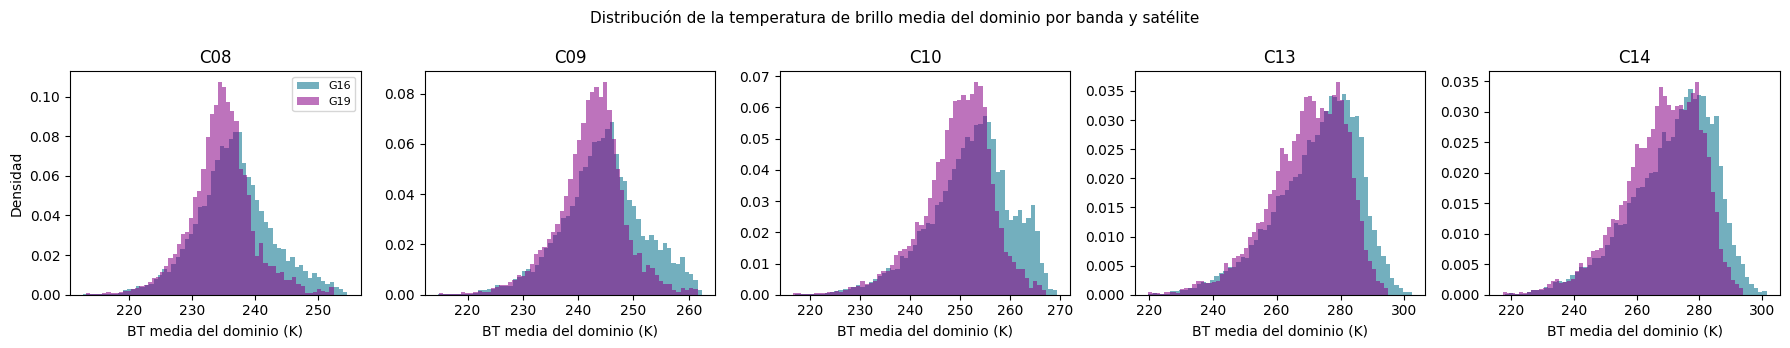

In [13]:
LIMITES_K = {"C08": (160, 300), "C09": (160, 310), "C10": (160, 320),
             "C13": (160, 340), "C14": (160, 340)}

qc["fuera_rango"] = False
for k, (lo, hi) in LIMITES_K.items():
    f = (qc[f"{k}_min"] < lo) | (qc[f"{k}_max"] > hi)
    qc.loc[f, "fuera_rango"] = True
    print(f"{k}: {f.sum():>6,} archivos fuera de [{lo}, {hi}] K   |   "
          f"mín. observado {qc[f'{k}_min'].min():.1f} K, máx. observado {qc[f'{k}_max'].max():.1f} K")

print(f"\nArchivos fuera de rango físico: {qc['fuera_rango'].sum():,}")

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=False)
for ax, k in zip(axes, BANDAS):
    for sat, col in [("G16", ROL["split_train"]), ("G19", ROL["split_test"])]:
        ax.hist(qc.loc[qc["satelite"] == sat, f"{k}_media"].dropna(), bins=60,
                alpha=0.55, color=col, label=sat, density=True)
    ax.set_title(k)
    ax.set_xlabel("BT media del dominio (K)")
axes[0].set_ylabel("Densidad")
axes[0].legend(fontsize=8)
fig.suptitle("Distribución de la temperatura de brillo media del dominio por banda y satélite", fontsize=11)
plt.tight_layout()
plt.show()

In [14]:
malo = qc[qc["fuera_rango"]]
print(malo[["timestamp", "satelite", "C10_min", "C10_media", "C10_max"]].to_string(index=False))

with xr.open_dataset(malo.iloc[0]["filepath"]) as ds:
    v = ds["CMI_C10"].values
print(f"Píxeles de C10 bajo 160 K: {(v < 160).sum()} de {v.size}")

                timestamp satelite    C10_min  C10_media   C10_max
2025-02-24 01:50:00+00:00      G16 126.910004 254.973712 263.00769
Píxeles de C10 bajo 160 K: 1 de 39402


Las temperaturas de brillo observadas se mantienen dentro de los límites físicos en todas las bandas, con una única excepción: un archivo presenta en C10 un mínimo de 126.9 K, un valor imposible para una banda de vapor de agua, que se atribuye a un defecto del escaneo y motiva su exclusión. Los mínimos del resto del registro, entre 177 y 182 K, corresponden a topes de convección profunda, y los máximos de las bandas de ventana, en torno a 320 K, a superficie calentada por la radiación solar en las zonas bajas del dominio; ambos extremos son físicamente plausibles.

Las distribuciones de ambos satélites difieren en las bandas de vapor de agua, donde GOES-16 presenta una cola hacia temperaturas de brillo más altas, indicativa de una troposfera más seca. Esta diferencia no es interpretable como un desajuste entre instrumentos, porque los dos satélites cubren períodos distintos: GOES-16 incluye la temporada seca y la sequía asociada a El Niño de 2024, mientras que GOES-19 cubre la segunda mitad de 2025. La comparación de calibración entre satélites, controlando por período, se desarrolla en `09-goes_intercalibration.ipynb`.

## Sección 6 — Consistencia temporal

Una imagen correcta se parece a sus vecinas: en 10 minutos la atmósfera cambia, pero de forma gradual. Una imagen con datos de otro timestamp, o con un defecto que no la vacía ni la duplica, aparece en cambio como un salto abrupto respecto de la imagen anterior **y** de la siguiente. La convección intensa también produce cambios rápidos, pero típicamente sostenidos, no un pico aislado que desaparece en el paso siguiente.

Se marca como **salto aislado** un archivo cuyo `rmsd_prev` y el de su sucesor superan ambos el percentil 99.9 de la banda para su satélite. Esta marca no excluye archivos de forma automática: identifica candidatos para inspección visual.

In [15]:
Q_SALTO = 0.999

qc["salto"] = False
for k in BANDAS:
    rmsd_sig = qc[f"{k}_rmsd_prev"].shift(-1)                 # rmsd del siguiente respecto de este
    siguiente_consec = (qc["timestamp"].shift(-1) - qc["timestamp"]) == PASO
    rmsd_sig = rmsd_sig.where(siguiente_consec)
    umbral = qc.groupby("satelite")[f"{k}_rmsd_prev"].transform(lambda s: s.quantile(Q_SALTO))
    f = (qc[f"{k}_rmsd_prev"] > umbral) & (rmsd_sig > umbral)
    qc.loc[f, "salto"] = True
    print(f"{k}: umbral p{Q_SALTO*100:.1f} = "
          f"{qc.groupby('satelite')[f'{k}_rmsd_prev'].quantile(Q_SALTO).round(2).to_dict()} K  |  "
          f"saltos aislados: {f.sum():,}")

print(f"\nArchivos con salto aislado en alguna banda: {qc['salto'].sum():,}")
print(f"  de ellos, ya marcados como contaminados: {(qc['salto'] & qc['contaminado']).sum():,}")

C08: umbral p99.9 = {'G16': 4.42, 'G19': 4.33} K  |  saltos aislados: 82
C09: umbral p99.9 = {'G16': 5.57, 'G19': 5.47} K  |  saltos aislados: 84
C10: umbral p99.9 = {'G16': 6.71, 'G19': 6.65} K  |  saltos aislados: 83
C13: umbral p99.9 = {'G16': 10.97, 'G19': 11.13} K  |  saltos aislados: 86
C14: umbral p99.9 = {'G16': 11.03, 'G19': 11.23} K  |  saltos aislados: 80

Archivos con salto aislado en alguna banda: 170
  de ellos, ya marcados como contaminados: 13


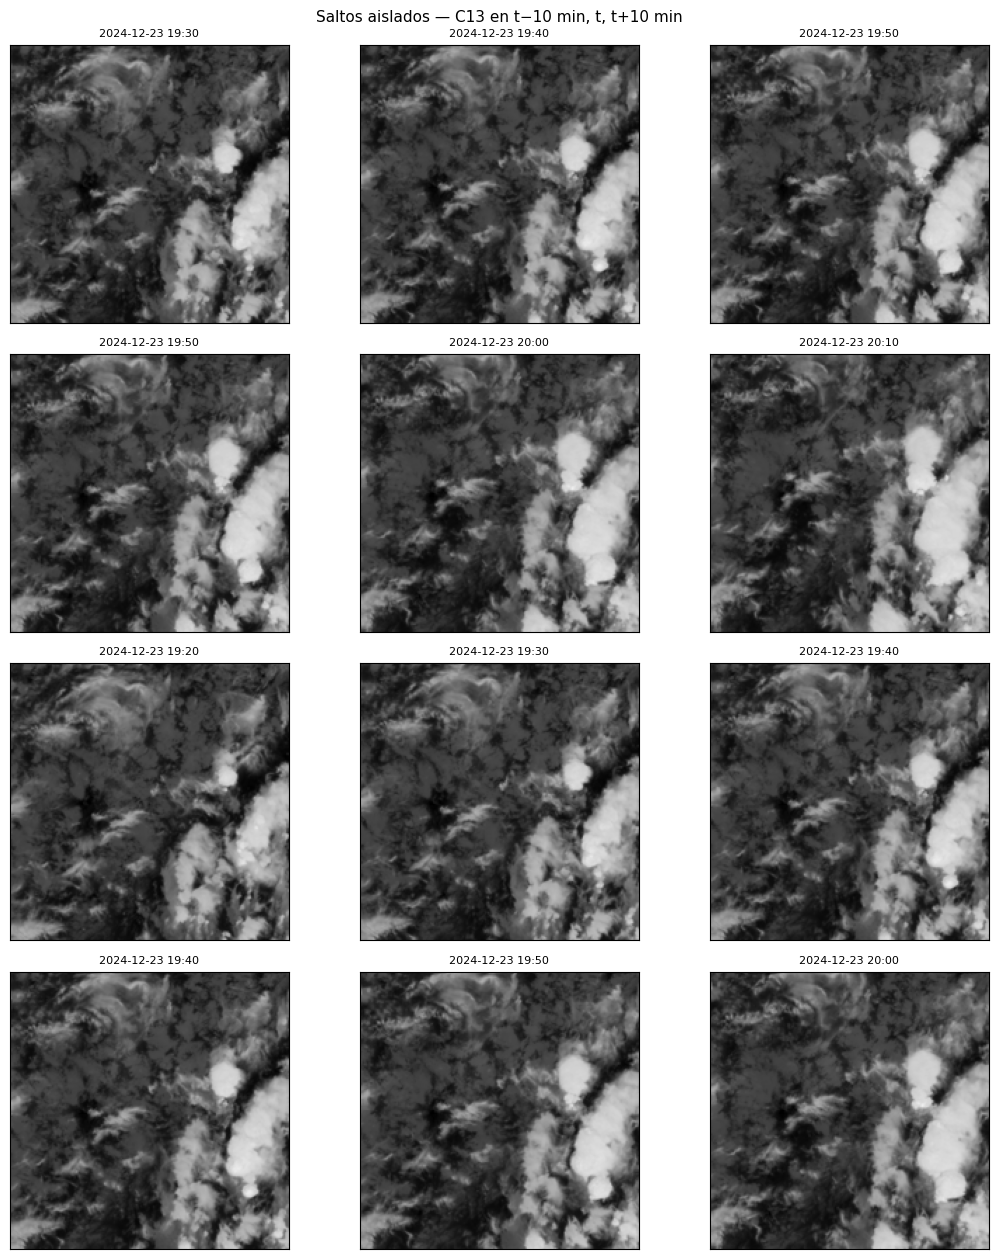

In [16]:
# Inspección visual: C13 en t−10 min, t y t+10 min para los saltos más marcados
candidatos = (qc[qc["salto"] & ~qc["contaminado"]]
              .sort_values("C13_rmsd_prev", ascending=False).head(4))

if len(candidatos):
    fig, axes = plt.subplots(len(candidatos), 3, figsize=(11, 3.2 * len(candidatos)), squeeze=False)
    for i, (idx, row) in enumerate(candidatos.iterrows()):
        for j, desp in enumerate([-1, 0, 1]):
            ax = axes[i, j]
            r = qc.loc[idx + desp] if 0 <= idx + desp < len(qc) else None
            if r is not None and r["C13_presente"]:
                with xr.open_dataset(r["filepath"]) as ds:
                    ax.imshow(ds["CMI_C13"].values, cmap="gray_r", vmin=190, vmax=300)
                ax.set_title(f"{r['timestamp']:%Y-%m-%d %H:%M}", fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle("Saltos aislados — C13 en t−10 min, t, t+10 min", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Sin saltos aislados fuera de los archivos ya marcados como contaminados.")

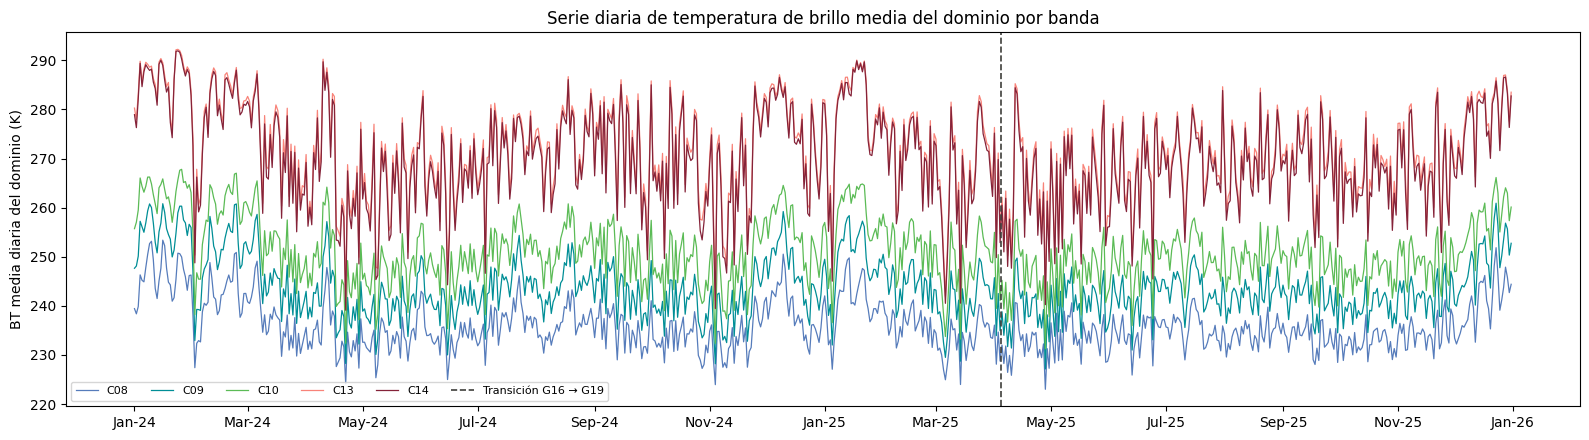

In [17]:
# Serie diaria de la BT media del dominio: continuidad a lo largo de los dos años
diaria = (qc.set_index("timestamp")[[f"{k}_media" for k in BANDAS]]
          .resample("D").mean())

fig, ax = plt.subplots(figsize=(16, 4.5))
colores = [PALETA["wi-darkblue"], PALETA["wwu-green"], PALETA["wi-green1"],
           PALETA["wi-coral"], PALETA["ercis-red"]]
for k, c in zip(BANDAS, colores):
    ax.plot(diaria.index.tz_localize(None), diaria[f"{k}_media"], lw=0.9, color=c, label=k)
ax.axvline(TRANSICION.tz_localize(None), color=ROL["linea_ref"], ls="--", lw=1.2,
           label="Transición G16 → G19")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
ax.set_ylabel("BT media diaria del dominio (K)")
ax.set_title("Serie diaria de temperatura de brillo media del dominio por banda")
ax.legend(fontsize=8, ncol=6, loc="lower left")
plt.tight_layout()
plt.show()

In [18]:
# Calibración: ¿detecta la Sección 6 los contaminados conocidos?
conocidos = qc["contaminado"]
detectados = conocidos & qc["salto"]
print(f"Contaminados conocidos: {conocidos.sum()}  |  detectados como salto: {detectados.sum()} "
      f"({detectados.sum() / conocidos.sum():.0%})")

# Magnitud del salto en los contaminados frente al resto
for k in BANDAS:
    print(f"{k}: rmsd_prev mediana — contaminados {qc.loc[conocidos, f'{k}_rmsd_prev'].median():.2f} K, "
          f"resto {qc.loc[~conocidos, f'{k}_rmsd_prev'].median():.2f} K, "
          f"p99.9 resto {qc.loc[~conocidos, f'{k}_rmsd_prev'].quantile(0.999):.2f} K")

Contaminados conocidos: 30  |  detectados como salto: 13 (43%)
C08: rmsd_prev mediana — contaminados 1.41 K, resto 1.36 K, p99.9 resto 4.36 K
C09: rmsd_prev mediana — contaminados 1.94 K, resto 1.83 K, p99.9 resto 5.47 K
C10: rmsd_prev mediana — contaminados 1.29 K, resto 2.40 K, p99.9 resto 6.67 K
C13: rmsd_prev mediana — contaminados 3.74 K, resto 4.70 K, p99.9 resto 11.03 K
C14: rmsd_prev mediana — contaminados 4.10 K, resto 4.75 K, p99.9 resto 11.08 K


El control de saltos aislados identifica 170 archivos, un 0.16% del registro. La inspección visual de los casos más marcados muestra que corresponden a convección real en rápida evolución, como la tormenta del 23 de diciembre de 2024 entre las 19:20 y las 20:10 UTC, y no a defectos de los archivos: el percentil 99.9 del cambio entre imágenes consecutivas selecciona, precisamente, los episodios convectivos más intensos. Estos archivos se conservan.

La sensibilidad del control frente a la contaminación se evaluó sobre los 30 archivos contaminados identificados en la Sección 4: solo 13 (43%) son detectados como salto, y su cambio respecto de la imagen anterior no difiere del resto del registro. Esto se explica porque la contaminación se produjo en bloques de timestamps consecutivos, dentro de los cuales las imágenes cruzadas mantienen continuidad entre sí, de modo que el salto solo se manifiesta en los bordes del bloque. El control de consistencia temporal es por tanto adecuado para detectar anomalías aisladas, pero no permite certificar la correspondencia entre el contenido de un archivo y su timestamp, que se verifica por muestreo contra la fuente en la sección siguiente.

La serie diaria de temperatura de brillo media del dominio es continua a lo largo de los dos años y no presenta discontinuidades en la transición entre GOES-16 y GOES-19; sus variaciones responden al ciclo estacional, con valores más altos en las temporadas secas.

## Sección 7 — Verificación contra la fuente (NOAA)

Los controles anteriores evalúan propiedades de los archivos que pueden verificarse sin salir del propio registro: su completitud, su unicidad, su rango físico y su continuidad temporal. Ninguno de ellos permite certificar que el contenido de un archivo corresponde al timestamp que indica su nombre. La Sección 6 mostró, además, que la contaminación ocurrida en bloques de timestamps consecutivos escapa al control de consistencia temporal.

La única verificación definitiva es la comparación con el producto original. Para cada archivo verificado se lee de forma remota, desde el repositorio público de NOAA, el mismo recorte del dominio que produjo `download_cmip.py`, y se compara píxel a píxel con el archivo local, banda por banda. La verificación se organiza en tres bloques:

- **A. Muestra aleatoria estratificada por mes** de los archivos que superaron los controles anteriores. Permite estimar la tasa de archivos erróneos en todo el registro, con una cota superior al 95% de confianza.
- **B. Ventanas de contaminación**, verificadas de forma exhaustiva con un margen de una hora a cada lado. Identifica todos los archivos cruzados, incluidos los intercambios que el control por hash no detecta, y valida que las ventanas de re-descarga sean suficientes.
- **C. Archivos excluidos** por incompletos, parciales o fuera de rango. Distingue los defectos presentes en el producto original de NOAA de las fallas de descarga recuperables.

### 7.1 Configuración y funciones

In [19]:
# ============================================================
# Sección 7 — Verificación contra la fuente (NOAA)
# ============================================================
import s3fs
from pyproj import Proj
from concurrent.futures import ProcessPoolExecutor, as_completed
from scipy.stats import beta

import re
PATRON_INICIO = re.compile(r"_s(\d{13})")   # sAAAADDDHHMMSS del nombre de archivo de NOAA

fs = s3fs.S3FileSystem(anon=True)

PRODUCTO_NOAA   = "ABI-L2-CMIPF"
BOUND           = {"lon": [-75.877, -72.277], "lat": [2.796, 6.396]}   # igual que download_cmip.py
RUTA_VERIF      = RUTA_SAT / "qc_verificacion_noaa.parquet"
RECALCULAR_NOAA = False
N_POR_MES       = 21                      # 24 meses × 21 ≈ 500 archivos en el bloque A
MARGEN_VENTANA  = pd.Timedelta("1h")
N_PRUEBA        = None                      # modo prueba: verifica solo N archivos. None = corrida completa
N_PROCESOS      = 16

# Ventanas de contaminación identificadas en la Sección 4 (UTC)
VENTANAS_REDESCARGA = [
    ("2024-02-15 14:50", "2024-02-15 15:20"),
    ("2024-04-20 06:00", "2024-04-20 10:00"),
    ("2024-09-29 22:00", "2024-09-30 02:00"),
]
qc["ventana_contaminacion"] = False
qc["ventana_ampliada"]      = False
for ini, fin in VENTANAS_REDESCARGA:
    ini, fin = pd.Timestamp(ini, tz="UTC"), pd.Timestamp(fin, tz="UTC")
    qc.loc[qc["timestamp"].between(ini, fin), "ventana_contaminacion"] = True
    qc.loc[qc["timestamp"].between(ini - MARGEN_VENTANA, fin + MARGEN_VENTANA), "ventana_ampliada"] = True

def bucket_de(t):
    return "noaa-goes16" if t < TRANSICION else "noaa-goes19"

_cache_ls, _cache_recorte = {}, {}
OFFSET = {}   # desplazamiento (dy, dx) del recorte por bucket, fijado en la calibración

def listar_hora(bucket, t):
    clave = (bucket, t.strftime("%Y%j%H"))
    if clave not in _cache_ls:
        try:
            _cache_ls[clave] = fs.ls(f"{bucket}/{PRODUCTO_NOAA}/{t:%Y}/{t:%j}/{t:%H}/")
        except FileNotFoundError:
            _cache_ls[clave] = []
    return _cache_ls[clave]

def indices_recorte(ds):
    """Replica el recorte de download_cmip.py: índices de fila y columna del dominio."""
    a = ds["goes_imager_projection"].attrs
    h = a["perspective_point_height"]
    p = Proj(proj="geos", h=h, lon_0=a["longitude_of_projection_origin"], sweep=a["sweep_angle_axis"])
    xmin, ymin = np.array(p(BOUND["lon"][0], BOUND["lat"][0])) / h
    xmax, ymax = np.array(p(BOUND["lon"][1], BOUND["lat"][1])) / h
    x, y = ds["x"].values, ds["y"].values
    sx = np.where((x >= xmin) & (x <= xmax))[0]
    sy = np.where((y >= ymin) & (y <= ymax))[0]
    return (int(sy.min()), int(sy.max()) + 1), (int(sx.min()), int(sx.max()) + 1)

def inicio_escaneo(nombre):
    m = PATRON_INICIO.search(nombre)
    return pd.to_datetime(m.group(1), format="%Y%j%H%M%S").tz_localize("UTC") if m else None

def leer_noaa(t, banda, margen=0):
    """Lee de NOAA solo el recorte del dominio (más un margen opcional). None si no existe."""
    bucket = bucket_de(t)
    cand = [f for f in listar_hora(bucket, t)
            if re.search(rf"-M\d{banda}_", f)
            and (ini := inicio_escaneo(f)) is not None and t <= ini < t + PASO]
    if not cand:
        return None
    with fs.open(cand[0], "rb") as fh, xr.open_dataset(fh, engine="h5netcdf") as ds:
        if bucket not in _cache_recorte:
            _cache_recorte[bucket] = indices_recorte(ds)
        (y0, y1), (x0, x1) = _cache_recorte[bucket]
        dy, dx = OFFSET.get(bucket, (0, 0)) if margen == 0 else (0, 0)
        return (ds["CMI"]
                .isel(y=slice(y0 + dy - margen, y1 + dy + margen),
                      x=slice(x0 + dx - margen, x1 + dx + margen))
                .values.astype("float64"))

def leer_local(fp, banda):
    with xr.open_dataset(fp) as ds:
        b = f"CMI_{banda}"
        return ds[b].values.astype("float64") if b in ds.variables else None

def comparar(t, fp, banda, bloque):
    fila = {"timestamp": t, "filepath": fp, "banda": banda, "bloque": bloque, "estado": None,
            "max_dif": np.nan, "frac_nan_local": np.nan, "frac_nan_noaa": np.nan, "detalle": None}
    try:
        loc, noaa = leer_local(fp, banda), leer_noaa(t, banda)
        if loc is not None:
            fila["frac_nan_local"] = float(np.isnan(loc).mean())
        if noaa is not None:
            fila["frac_nan_noaa"] = float(np.isnan(noaa).mean())
        if noaa is None and loc is None:
            fila["estado"] = "falta_ambos"
        elif noaa is None:
            fila["estado"] = "falta_noaa"
        elif loc is None:
            fila["estado"] = "falta_local"
        elif loc.shape != noaa.shape:
            fila["estado"] = "forma_distinta"
        elif np.array_equal(loc, noaa, equal_nan=True):
            fila["estado"] = "igual"
        else:
            fila["estado"] = "distinto"
            d = np.abs(loc - noaa)
            fila["max_dif"] = float(np.nanmax(d)) if np.isfinite(d).any() else np.nan
    except Exception as e:
        fila["estado"], fila["detalle"] = "error", str(e)[:80]
    return fila

### 7.2 Calibración del recorte

In [20]:
# Antes de verificar nada, se comprueba que el recorte remoto reproduce exactamente
# archivos locales sanos. Se buscan desplazamientos de hasta 2 píxeles, por si el
# redondeo de coordenadas difiere entre librerías.
M = 2
sanos = qc[~(qc["incompleto"] | qc["parcial"] | qc["contaminado"] | qc["ventana_ampliada"])]
#ref = sanos.groupby("satelite", group_keys=False).apply(lambda g: g.sample(2, random_state=0))
ref = sanos.groupby("satelite").sample(n=2, random_state=0)

coincidencias = []
for _, r in ref.iterrows():
    loc = leer_local(r["filepath"], "C13")
    big = leer_noaa(r["timestamp"], "C13", margen=M)
    if big is None:
        print(f"⚠️  {r['timestamp']}: no se encontró en NOAA")
        continue
    for dy in range(-M, M + 1):
        for dx in range(-M, M + 1):
            sub = big[M + dy: M + dy + loc.shape[0], M + dx: M + dx + loc.shape[1]]
            if sub.shape == loc.shape and np.array_equal(sub, loc, equal_nan=True):
                coincidencias.append({"bucket": bucket_de(r["timestamp"]), "dy": dy, "dx": dx})

coincidencias = pd.DataFrame(coincidencias)
print(coincidencias.value_counts().to_string() if len(coincidencias) else "Sin coincidencias")

for bucket in ref["timestamp"].map(bucket_de).unique():
    c = coincidencias[coincidencias["bucket"] == bucket] if len(coincidencias) else coincidencias
    assert len(c), (f"⚠️ Ningún desplazamiento reproduce los archivos locales en {bucket} — "
                    "revisar el recorte antes de continuar")
    dy, dx = c[["dy", "dx"]].value_counts().index[0]
    OFFSET[bucket] = (int(dy), int(dx))
    print(f"✓ {bucket}: recorte calibrado con desplazamiento (dy, dx) = ({dy}, {dx})")

bucket       dy  dx
noaa-goes16  0   0     2
noaa-goes19  0   0     2
✓ noaa-goes16: recorte calibrado con desplazamiento (dy, dx) = (0, 0)
✓ noaa-goes19: recorte calibrado con desplazamiento (dy, dx) = (0, 0)


### 7.3 Ejecución

In [21]:
N_C = 60

utilizable = ~(qc["incompleto"] | qc["parcial"] | qc["fuera_rango"] |
               qc["contaminado"] | qc["ventana_ampliada"])

bloque_a = qc[utilizable].groupby("mes").sample(n=N_POR_MES, random_state=42)
bloque_b = qc[qc["ventana_ampliada"]]
bloque_c = (qc[(qc["incompleto"] | qc["parcial"] | qc["fuera_rango"]) & ~qc["ventana_ampliada"]]
            .sample(n=N_C, random_state=42))

a_verificar = pd.concat([bloque_a.assign(bloque="A"),
                         bloque_b.assign(bloque="B"),
                         bloque_c.assign(bloque="C")])[["timestamp", "filepath", "bloque"]]
print(a_verificar["bloque"].value_counts().sort_index().to_string())

modo_prueba = N_PRUEBA is not None
if modo_prueba:
    a_verificar = a_verificar.sample(N_PRUEBA, random_state=1)
    print(f"\n⚠️  MODO PRUEBA: {N_PRUEBA} archivos, sin guardar resultados")

RUTA_PARCIAL = RUTA_SAT / "qc_verificacion_noaa_parcial.parquet"

if RUTA_VERIF.exists() and not RECALCULAR_NOAA and not modo_prueba:
    verif = pd.read_parquet(RUTA_VERIF)
    print(f"\n✓ Verificación cargada desde {RUTA_VERIF.name}")
else:
    from verificacion_noaa import verificar_archivo
    # Recorte calibrado en la 7.2, por satélite
    recortes = {b: (_cache_recorte[b][0], _cache_recorte[b][1], OFFSET[b]) for b in OFFSET}

    # Retomar una corrida interrumpida
    hechas = pd.DataFrame()
    if RUTA_PARCIAL.exists() and not modo_prueba:
        hechas = pd.read_parquet(RUTA_PARCIAL)
    pendientes = (a_verificar[~a_verificar["filepath"].isin(hechas["filepath"])]
                  if len(hechas) else a_verificar)
    if len(hechas):
        print(f"\nRetomando: {hechas['filepath'].nunique()} archivos ya verificados, "
              f"{len(pendientes)} pendientes")

    filas = []
    with ProcessPoolExecutor(max_workers=N_PROCESOS) as ex:
        futuros = [ex.submit(verificar_archivo, r.timestamp, r.filepath, r.bloque, recortes, TRANSICION)
                   for r in pendientes.itertuples(index=False)]
        for i, f in enumerate(tqdm(as_completed(futuros), total=len(futuros),
                                   desc="Verificación NOAA (archivos)"), start=1):
            filas.extend(f.result())
            if not modo_prueba and i % 20 == 0:
                pd.concat([hechas, pd.DataFrame(filas)]).to_parquet(RUTA_PARCIAL, index=False)

    verif = pd.concat([hechas, pd.DataFrame(filas)], ignore_index=True)
    if not modo_prueba:
        verif.to_parquet(RUTA_VERIF, index=False)
        RUTA_PARCIAL.unlink(missing_ok=True)
        print(f"\n✓ Verificación guardada en {RUTA_VERIF.name}")

print("\nEstado por bloque (banda-archivo):")
print(verif.groupby(["bloque", "estado"]).size().unstack(fill_value=0).to_string())
if (verif["estado"] == "error").any():
    print("\nErrores:")
    print(verif.loc[verif["estado"] == "error", "detalle"].value_counts().head().to_string())

bloque
A    504
B     80
C     60

✓ Verificación cargada desde qc_verificacion_noaa.parquet

Estado por bloque (banda-archivo):
estado  distinto  falta_ambos  falta_local  falta_noaa  igual
bloque                                                       
A              0            0            0           0   2520
B             47            0            6          10    337
C              0           57            0           0    243


### 7.4 Bloque A: tasa de error en el registro

**El registro general está validado**: 504 archivos, 2,520 bandas, todas idénticas a NOAA. La cota superior es 0.59%: con un 95% de confianza, menos del 0.6% de los archivos fuera de las ventanas podría estar mal.

Se podría afirmar que los archivos únicos contienen el dato de su timestamp.

In [22]:
piv = verif.pivot_table(index=["bloque", "timestamp", "filepath"], columns="banda",
                        values="estado", aggfunc="first")
ERRONEO = ["distinto", "falta_noaa", "forma_distinta"]

pa = piv.loc["A"]
validos     = pa[~(pa == "error").any(axis=1)]
incorrectos = validos[validos.isin(ERRONEO).any(axis=1)]
n, k = len(validos), len(incorrectos)
cota = beta.ppf(0.95, k + 1, n - k)

print(f"Archivos verificados: {n}  |  incorrectos: {k}")
print(f"Cota superior (95%) de la fracción de archivos erróneos en el registro: {cota:.2%}")
if k:
    print(incorrectos.to_string())

Archivos verificados: 504  |  incorrectos: 0
Cota superior (95%) de la fracción de archivos erróneos en el registro: 0.59%


### 7.5 Bloque B: ventanas de contaminación

- **21 archivos incorrectos**, todos dentro de las ventanas de re-descarga. Ninguno aparece fuera, así que las ventanas alcanzan.
- **5 de ellos son intercambios que el hash no podía detectar**: 20 de abril a las 07:30 y 07:40, y 29 de septiembre a las 23:00, 23:20 y 23:30. Justo las 07:30 y las 07:40 eran los dos huecos sospechosos que se habían notado dentro del tramo de abril.
- **14 archivos marcados por hash están correctos**. Tiene sentido: en cada par duplicado, uno de los dos tenía el dato original y el otro la copia. El hash no podía distinguir cuál era cuál; NOAA sí.

Hay un caso especial: Los dos archivos del 15 de febrero (15:00 y 15:10) están mal en las cinco bandas. Si uno fuera copia del otro, al menos uno debería coincidir con NOAA. Puede ser que corresponden a los 10 falta_noaa de la tabla: NOAA no tendría esos dos escaneos (5 bandas × 2 archivos = 10), y el gap de ese día sería más largo de lo que muestra el inventario. Los archivos descargados originalmente contendrían datos de otro momento, quizás de antes del gap. Si es así, esos dos archivos no se re-descargan: se excluyen, porque no hay nada que bajar.

In [23]:
pb = piv.loc["B"].copy()
pb["bandas_incorrectas"] = pb.apply(lambda r: ", ".join(b for b in BANDAS if r[b] in ERRONEO), axis=1)
pb = pb.reset_index().merge(qc[["filepath", "contaminado", "ventana_contaminacion"]], on="filepath")
pb["incorrecto"] = pb["bandas_incorrectas"] != ""

print(f"Archivos en ventanas ampliadas: {len(pb)}  |  incorrectos: {pb['incorrecto'].sum()}")
print(f"  detectados por hash (Sección 4): {(pb['incorrecto'] & pb['contaminado']).sum()}")
print(f"  solo detectables contra NOAA (intercambios): {(pb['incorrecto'] & ~pb['contaminado']).sum()}")
print(f"  marcados por hash pero correctos: {(~pb['incorrecto'] & pb['contaminado']).sum()}")
print(f"  incorrectos FUERA de las ventanas de re-descarga: "
      f"{(pb['incorrecto'] & ~pb['ventana_contaminacion']).sum()}")

print("\nArchivos incorrectos:")
print(pb.loc[pb["incorrecto"], ["timestamp", "bandas_incorrectas", "contaminado"]].to_string(index=False))

Archivos en ventanas ampliadas: 80  |  incorrectos: 21
  detectados por hash (Sección 4): 16
  solo detectables contra NOAA (intercambios): 5
  marcados por hash pero correctos: 14
  incorrectos FUERA de las ventanas de re-descarga: 0

Archivos incorrectos:
                timestamp      bandas_incorrectas  contaminado
2024-02-15 15:00:00+00:00 C08, C09, C10, C13, C14         True
2024-02-15 15:10:00+00:00 C08, C09, C10, C13, C14         True
2024-04-20 06:50:00+00:00           C08, C09, C10         True
2024-04-20 07:00:00+00:00                C08, C14         True
2024-04-20 07:10:00+00:00                     C08         True
2024-04-20 07:20:00+00:00           C09, C10, C14         True
2024-04-20 07:30:00+00:00                C08, C09        False
2024-04-20 07:40:00+00:00                C08, C09        False
2024-04-20 08:30:00+00:00           C08, C09, C10         True
2024-04-20 08:40:00+00:00      C08, C09, C10, C14         True
2024-04-20 09:00:00+00:00      C08, C09, C13, C14

### 7.6 Bloque C: ¿defecto de NOAA o falla de descarga?

Ninguno de los 60 es recuperable. En todos, NOAA tiene exactamente el mismo defecto que tu archivo: las bandas faltantes tampoco existen en NOAA (57 falta_ambos), y las presentes coinciden (243 igual). _Con 0 recuperables en 60, se puede afirmar con un 95% de confianza que menos del 5% de los 245 excluidos sería recuperable desde CMIP_. Los defectos son del producto de NOAA, no de la descarga, así que no vale la pena intentar re-descargarlos. Los 169 positivos que se pierden por archivos incompletos son una pérdida real, salvo la vía de L1b.

In [24]:
pc_estado = piv.loc["C"]
pc_nan = verif[verif["bloque"] == "C"].pivot_table(index=["timestamp", "filepath"], columns="banda",
                                                   values="frac_nan_noaa", aggfunc="first")

noaa_completo = (~pc_estado.isin(["falta_noaa", "falta_ambos", "error"]).any(axis=1) &
                 (pc_nan.max(axis=1) < UMBRAL_NAN_PARCIAL))
todo_igual    = (pc_estado == "igual").all(axis=1)
recuperable   = noaa_completo & ~todo_igual

print(f"Archivos excluidos verificados: {len(pc_estado)}")
print(f"  recuperables (NOAA tiene el dato completo): {recuperable.sum()}")
print(f"  defecto presente en NOAA (no recuperable): {(~recuperable).sum()}")

# Marcas para las listas de salida
incorrectos_ab = set(incorrectos.index.get_level_values("filepath")) | set(pb.loc[pb["incorrecto"], "filepath"])
recuperables   = set(recuperable[recuperable].index.get_level_values("filepath"))
qc["verif_incorrecto"] = qc["filepath"].isin(incorrectos_ab)
qc["recuperable"]      = qc["filepath"].isin(recuperables)

Archivos excluidos verificados: 60
  recuperables (NOAA tiene el dato completo): 0
  defecto presente en NOAA (no recuperable): 60


In [25]:
b = verif[verif["bloque"] == "B"]

print("falta_noaa (el archivo local tiene la banda, NOAA no):")
print(b.loc[b["estado"] == "falta_noaa", ["timestamp", "banda"]].to_string(index=False))

print("\nfalta_local (NOAA tiene la banda, el archivo local no):")
print(b.loc[b["estado"] == "falta_local", ["timestamp", "banda", "frac_nan_noaa"]].to_string(index=False))

falta_noaa (el archivo local tiene la banda, NOAA no):
                timestamp banda
2024-02-15 15:00:00+00:00   C08
2024-02-15 15:00:00+00:00   C09
2024-02-15 15:00:00+00:00   C10
2024-02-15 15:00:00+00:00   C13
2024-02-15 15:00:00+00:00   C14
2024-02-15 15:10:00+00:00   C08
2024-02-15 15:10:00+00:00   C09
2024-02-15 15:10:00+00:00   C10
2024-02-15 15:10:00+00:00   C13
2024-02-15 15:10:00+00:00   C14

falta_local (NOAA tiene la banda, el archivo local no):
                timestamp banda  frac_nan_noaa
2024-04-20 07:40:00+00:00   C10            0.0
2024-04-20 07:30:00+00:00   C10            0.0
2024-04-20 07:30:00+00:00   C13            0.0
2024-04-20 07:10:00+00:00   C09            0.0
2024-04-20 07:10:00+00:00   C10            0.0
2024-04-20 07:10:00+00:00   C13            0.0


### Conclusión de la sección 7

La calibración del recorte reproduce exactamente, píxel a píxel, los archivos locales de ambos satélites sin necesidad de desplazamiento, lo que garantiza que cualquier diferencia posterior refleja una diferencia real de contenido y no un artefacto del método.

**Bloque A.** Los 504 archivos de la muestra aleatoria coinciden exactamente con el producto original de NOAA en sus cinco bandas. Con cero discrepancias en 504 archivos, la fracción de archivos erróneos en el registro, fuera de las ventanas de contaminación, es inferior al 0.59% con un 95% de confianza.

**Bloque B.** La verificación exhaustiva de las 80 imágenes de las ventanas ampliadas identifica 21 archivos incorrectos, todos dentro de las ventanas de re-descarga, lo que confirma que estas son suficientes. Cinco de ellos (20 de abril a las 07:30 y 07:40; 29 de septiembre a las 23:00, 23:20 y 23:30) no presentan contenido duplicado y corresponden a intercambios de datos entre los dos procesos de descarga simultáneos, indetectables por el control de hash. A la inversa, 14 archivos marcados como contaminados por hash resultan correctos: en cada par duplicado, uno de los dos conserva el dato original. Los dos archivos del 15 de febrero son incorrectos en las cinco bandas, porque NOAA no dispone de esos escaneos: el script de descarga generó ambos archivos con restos de un timestamp anterior.

**Bloque C.** Ninguno de los 60 archivos excluidos de la muestra es recuperable: en todos los casos, el producto de NOAA presenta el mismo defecto que el archivo local, ya sea la ausencia de la banda o su contenido vacío. Con cero recuperables en 60, la fracción recuperable del conjunto de archivos excluidos es inferior al 5% con un 95% de confianza. Los defectos de completitud identificados en la Sección 3 son, por tanto, propios del producto original y no de la descarga.

**_En consecuencia, se re-descargan 19 archivos, los incorrectos cuyo dato completo existe en NOAA, y se excluyen definitivamente los dos del 15 de febrero junto con los archivos incompletos, parciales o fuera de rango._**

## Sección 8 — Geometría del recorte

Todas las etapas posteriores ubican cada estación en la imagen mediante coordenadas fijas de píxel (`fila`, `col`), calculadas una sola vez. Eso solo es válido si todos los archivos comparten exactamente la misma grilla. GOES-16 y GOES-19 operan desde la misma posición orbital (75.2°O), por lo que el recorte debería ser idéntico en ambos satélites.

In [26]:
geom = (qc.dropna(subset=["ny"])
        .assign(lat0=lambda d: d["lat0"].round(4), lon0=lambda d: d["lon0"].round(4))
        .groupby(["satelite", "ny", "nx", "lat0", "lon0"]).size()
        .rename("n_archivos").reset_index())
print(geom.to_string(index=False))

grilla_ref = geom.sort_values("n_archivos", ascending=False).iloc[0]
qc["geometria_distinta"] = (qc["ny"].notna() &
                            ((qc["ny"] != grilla_ref["ny"]) | (qc["nx"] != grilla_ref["nx"]) |
                             (qc["lat0"].round(4) != grilla_ref["lat0"]) |
                             (qc["lon0"].round(4) != grilla_ref["lon0"])))
print(f"\nGrilla de referencia: {int(grilla_ref['ny'])}×{int(grilla_ref['nx'])}, "
      f"esquina ({grilla_ref['lat0']}, {grilla_ref['lon0']})")
print(f"Archivos con geometría distinta: {qc['geometria_distinta'].sum():,}")

satelite  ny  nx   lat0     lon0  n_archivos
     G16 198 199 6.3914 -75.8797       65848
     G19 198 199 6.3914 -75.8797       39062

Grilla de referencia: 198×199, esquina (6.3914, -75.8797)
Archivos con geometría distinta: 0


Los 104,910 archivos comparten una única grilla de 198 × 199 píxeles, con la esquina noroeste en 6.3914° N y 75.8797° O, idéntica en GOES-16 y GOES-19, en coherencia con la posición orbital común de ambos satélites. Ningún archivo presenta una geometría distinta, de modo que las coordenadas de píxel de cada estación, calculadas una única vez, son válidas para todo el registro.

## Sección 9 — Listas de salida

Los resultados de las secciones anteriores se consolidan en dos listas:

- **Exclusión** (`qc_exclusion_goes.csv`): archivos inutilizables cuyo dato no existe o no es confiable — ilegibles, con banda ausente o vacía, parciales por encima del umbral, fuera de rango físico o con geometría distinta. `11-dataset_training.ipynb` los elimina del inventario antes del cruce con las etiquetas.
- **Re-descarga** (`qc_redescarga_goes.csv`): archivos contaminados, cuyo dato existe en NOAA pero se guardó mal. Mientras no se re-descarguen, también se excluyen.

Los saltos aislados de la Sección 6 no entran automáticamente en ninguna lista: se incorporan solo si la inspección visual confirma que son artefactos.

In [27]:
MOTIVOS = ["incompleto", "parcial", "fuera_rango", "geometria_distinta", "verif_incorrecto"]

# Un archivo se puede reponer solo si NOAA tiene sus cinco bandas
noaa_completo = (verif.groupby("filepath")["estado"]
                 .agg(lambda s: not s.isin(["falta_noaa", "falta_ambos"]).any()))
qc["noaa_completo"] = qc["filepath"].map(noaa_completo).eq(True)

# Bandas ausentes localmente que NOAA sí tiene
falta_local = verif.loc[verif["estado"] == "falta_local", "filepath"].unique()
qc["falta_local_reponible"] = qc["filepath"].isin(falta_local)

qc["motivo"]  = qc[MOTIVOS].apply(lambda r: ", ".join(m for m in MOTIVOS if r[m]), axis=1)
qc["excluir"] = qc[MOTIVOS].any(axis=1)

excluir    = qc.loc[qc["excluir"], ["timestamp", "satelite", "filepath", "motivo"]]
redescarga = qc.loc[(qc["verif_incorrecto"] | qc["recuperable"] | qc["falta_local_reponible"])
                    & qc["noaa_completo"],
                    ["timestamp", "satelite", "filepath"]]

excluir.to_csv(RUTA_EXCLUIR, index=False)
redescarga.to_csv(RUTA_REDESC, index=False)

resumen_final = pd.DataFrame({m: qc.groupby("satelite")[m].sum() for m in MOTIVOS})
resumen_final["total_excluidos"] = qc.groupby("satelite")["excluir"].sum()
resumen_final["archivos"]        = qc.groupby("satelite").size()
resumen_final["frac_excluida"]   = (resumen_final["total_excluidos"] / resumen_final["archivos"]).map("{:.3%}".format)
print(resumen_final.to_string())

print(f"\n✓ {RUTA_EXCLUIR.name}: {len(excluir):,} archivos")
print(f"✓ {RUTA_REDESC.name}: {len(redescarga):,} archivos (timestamps en UTC)")

# Verificación: el salto no es motivo de exclusión
saltos_excluidos = qc[qc["salto"] & qc["excluir"]]
print(f"\nArchivos con salto: {qc['salto'].sum():,}  |  conservados: {(qc['salto'] & ~qc['excluir']).sum():,}  "
      f"|  excluidos por otro motivo: {len(saltos_excluidos):,}")
if len(saltos_excluidos):
    print(saltos_excluidos["motivo"].value_counts().to_string())
assert not (qc["salto"] & qc["excluir"] & (qc["motivo"] == "")).any(), \
    "⚠️ Hay archivos excluidos solo por salto"

          incompleto  parcial  fuera_rango  geometria_distinta  verif_incorrecto  total_excluidos  archivos frac_excluida
satelite                                                                                                                 
G16              161       27            1                   0                21              207     65848        0.314%
G19               44       15            0                   0                 0               59     39062        0.151%

✓ qc_exclusion_goes.csv: 266 archivos
✓ qc_redescarga_goes.csv: 19 archivos (timestamps en UTC)

Archivos con salto: 170  |  conservados: 159  |  excluidos por otro motivo: 11
motivo
verif_incorrecto                10
incompleto, verif_incorrecto     1


**Resultado.** Se excluyen 266 archivos, un 0.25% del registro: 207 de GOES-16 (0.31%) y 59 de GOES-19 (0.15%). La mayor parte corresponde a defectos propios del producto de NOAA, con bandas ausentes, vacías o parciales (247 archivos), y el resto a archivos cuyo contenido no coincide con la fuente (21). Ningún archivo presenta una geometría distinta, y solo uno supera los límites físicos de temperatura de brillo.

De los 21 archivos incorrectos, 19 se re-descargan, porque NOAA dispone del dato completo; los dos restantes, del 15 de febrero de 2024, se excluyen de forma definitiva, ya que el escaneo no existe en la fuente. Mientras no se complete la re-descarga, los 19 archivos permanecen en la lista de exclusión.

Los 170 archivos marcados como saltos aislados en la Sección 6 no constituyen un motivo de exclusión: 159 se conservan, y los 11 restantes se excluyen por no coincidir con la fuente, como parte de las ventanas de contaminación.

## Sección 10 — Re-descarga y verificación final

Los 19 archivos incorrectos cuyo dato completo existe en NOAA (Sección 9) se re-descargan con una versión corregida de `download_cmip.py`, que procesa cada timestamp en una carpeta temporal propia, selecciona únicamente escaneos cuyo inicio corresponde al timestamp, valida la completitud de las cinco bandas antes de escribir y registra la procedencia de cada archivo. Los archivos reemplazados se conservan en `data/cmip_reemplazados/`.

Esta sección somete los archivos re-descargados a los mismos controles de las secciones anteriores (completitud, integridad, rango físico y geometría) y a la verificación contra la fuente, y produce la lista de exclusión definitiva. Las Secciones 1 a 9 documentan el diagnóstico de la descarga original.

In [4]:
import shutil
shutil.copy(RUTA_QC,    RUTA_SAT / "qc_archivos_goes_descarga_original.parquet")
shutil.copy(RUTA_SAT / "qc_verificacion_noaa.parquet",
            RUTA_SAT / "qc_verificacion_noaa_descarga_original.parquet")
print("✓ Copia de la verificación original guardada")
print("✓ Copias de la descarga original guardadas")

✓ Copia de la verificación original guardada
✓ Copias de la descarga original guardadas


### 10.1 Controles internos

In [28]:
# ============================================================
# 10.1 — Controles internos sobre los archivos re-descargados
# ============================================================
redesc = pd.read_csv(RUTA_REDESC)
redesc["timestamp"] = pd.to_datetime(redesc["timestamp"], utc=True)
nuevos = archivos_df[archivos_df["filepath"].isin(redesc["filepath"])]
qc_nuevos = estadisticas_archivos(nuevos)

# Completitud
for k in BANDAS:
    qc_nuevos[f"{k}_ok"] = (qc_nuevos[f"{k}_presente"].fillna(False).astype(bool) &
                            (qc_nuevos[f"{k}_frac_nan"] < UMBRAL_NAN_PARCIAL))
qc_nuevos["completo"] = qc_nuevos[[f"{k}_ok" for k in BANDAS]].all(axis=1)

# Integridad: ninguna banda idéntica a la de otro archivo del registro
otros = qc[~qc["filepath"].isin(nuevos["filepath"])]
qc_nuevos["duplicado"] = False
for k in BANDAS:
    qc_nuevos.loc[qc_nuevos[f"{k}_hash"].isin(otros[f"{k}_hash"].dropna()), "duplicado"] = True

# Rango físico
qc_nuevos["fuera_rango"] = False
for k, (lo, hi) in LIMITES_K.items():
    qc_nuevos.loc[(qc_nuevos[f"{k}_min"] < lo) | (qc_nuevos[f"{k}_max"] > hi), "fuera_rango"] = True

# Geometría
qc_nuevos["geometria_ok"] = ((qc_nuevos["ny"] == grilla_ref["ny"]) & (qc_nuevos["nx"] == grilla_ref["nx"]) &
                             (qc_nuevos["lat0"].round(4) == grilla_ref["lat0"]) &
                             (qc_nuevos["lon0"].round(4) == grilla_ref["lon0"]))

print(f"Archivos re-descargados: {len(qc_nuevos)}")
print(f"  completos (cinco bandas, sin píxeles faltantes): {qc_nuevos['completo'].sum()}")
print(f"  con alguna banda duplicada de otro archivo:      {qc_nuevos['duplicado'].sum()}")
print(f"  fuera de rango físico:                           {qc_nuevos['fuera_rango'].sum()}")
print(f"  con la geometría de referencia:                  {qc_nuevos['geometria_ok'].sum()}")

QC satelital: 100%|██████████| 19/19 [00:00<00:00, 33.10it/s]


Archivos re-descargados: 19
  completos (cinco bandas, sin píxeles faltantes): 19
  con alguna banda duplicada de otro archivo:      0
  fuera de rango físico:                           0
  con la geometría de referencia:                  19


Los 19 archivos re-descargados superan todos los controles internos: contienen las cinco bandas sin píxeles faltantes, ninguna de sus bandas coincide con la de otro archivo del registro, sus temperaturas de brillo se mantienen dentro de los límites físicos y comparten la grilla de referencia. Los tres archivos del 20 de abril que en la descarga original carecían de alguna banda quedan completos.

### 10.2 Verificación contra NOAA

In [29]:
# ============================================================
# 10.2 — Verificación de los archivos re-descargados contra NOAA
# ============================================================
from verificacion_noaa import verificar_archivo
recortes = {b: (_cache_recorte[b][0], _cache_recorte[b][1], OFFSET[b]) for b in OFFSET}

filas = []
with ProcessPoolExecutor(max_workers=N_PROCESOS) as ex:
    futuros = [ex.submit(verificar_archivo, r.timestamp, r.filepath, "R", recortes, TRANSICION)
               for r in nuevos.itertuples(index=False)]
    for f in tqdm(as_completed(futuros), total=len(futuros), desc="Verificación NOAA (re-descarga)"):
        filas.extend(f.result())
verif_nuevos = pd.DataFrame(filas)

print(verif_nuevos["estado"].value_counts().to_string())
iguales = verif_nuevos.groupby("filepath")["estado"].apply(lambda s: (s == "igual").all())
print(f"\nArchivos idénticos a NOAA en las cinco bandas: {iguales.sum()} de {len(iguales)}")

Verificación NOAA (re-descarga): 100%|██████████| 19/19 [11:54<00:00, 37.61s/it]  


estado
igual    95

Archivos idénticos a NOAA en las cinco bandas: 19 de 19


Los 19 archivos re-descargados coinciden exactamente con el producto original de NOAA en sus cinco bandas (95 de 95 comparaciones), verificados con el mismo procedimiento de la Sección 7. La re-descarga corrige por tanto la totalidad de los archivos incorrectos cuyo dato existe en la fuente.

### 10.3 Lista de exclusión final

In [30]:
# ============================================================
# 10.3 — Lista de exclusión final
# ============================================================
validos = qc_nuevos.set_index("filepath")
validos = validos[validos["completo"] & ~validos["duplicado"] & ~validos["fuera_rango"] & validos["geometria_ok"]]
repuestos = set(validos.index) & set(iguales[iguales].index)

qc["repuesto"]      = qc["filepath"].isin(repuestos)
qc["excluir_final"] = qc["excluir"] & ~qc["repuesto"]

excluir_final = qc.loc[qc["excluir_final"], ["timestamp", "satelite", "filepath", "motivo"]]
excluir_final.to_csv(RUTA_EXCLUIR, index=False)

pendientes = set(redesc["filepath"]) - repuestos
resumen = pd.DataFrame({
    "excluidos_diagnostico": qc.groupby("satelite")["excluir"].sum(),
    "repuestos":             qc.groupby("satelite")["repuesto"].sum(),
    "excluidos_final":       qc.groupby("satelite")["excluir_final"].sum(),
    "archivos":              qc.groupby("satelite").size(),
})
resumen["frac_excluida"] = (resumen["excluidos_final"] / resumen["archivos"]).map("{:.3%}".format)
print(resumen.to_string())
print(f"\n✓ {RUTA_EXCLUIR.name}: {len(excluir_final):,} archivos (lista definitiva)")
print(f"Re-descargas pendientes: {len(pendientes)}")

          excluidos_diagnostico  repuestos  excluidos_final  archivos frac_excluida
satelite                                                                           
G16                         207         19              188     65848        0.286%
G19                          59          0               59     39062        0.151%

✓ qc_exclusion_goes.csv: 247 archivos (lista definitiva)
Re-descargas pendientes: 0


**Resultado final.** Tras la reposición de los 19 archivos, la lista definitiva de exclusión reúne 247 archivos, un 0.24% del registro: 188 de GOES-16 (0.29%) y 59 de GOES-19 (0.15%). Todos corresponden a defectos presentes en el producto original de NOAA (202 archivos con bandas ausentes o vacías, 42 con más del 5% de píxeles sin dato y uno con valores físicamente imposibles) o a escaneos inexistentes en la fuente (los dos del 15 de febrero de 2024), por lo que ninguno es recuperable desde el producto CMIP. No quedan re-descargas pendientes.

Los 104,663 archivos restantes han superado controles de completitud, integridad, rango físico y geometría, y su correspondencia con la fuente está respaldada por la verificación exhaustiva de las ventanas de contaminación y por una muestra aleatoria de 504 archivos sin ninguna discrepancia, que acota la fracción de archivos erróneos por debajo del 0.59% con un 95% de confianza. La lista `qc_exclusion_goes.csv` se aplica en `11-dataset_training.ipynb` antes del cruce con las etiquetas.